In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import re
import glob
import os

In [ ]:
!pip install striprtf

In [ ]:
from striprtf.striprtf import rtf_to_text

In [ ]:
PATH = "/content/drive/MyDrive/Nachrichten"

txt_files = glob.glob(
    f"{PATH}/**/*.txt",
    recursive=True
)

print(f"Found {len(txt_files)} files")

Found 28 files


In [ ]:
all_data = []

for filename in txt_files:

    print(f"Processing: {filename}")

    with open(
        filename,
        "r",
        encoding="utf-8",
        errors="ignore"
    ) as f:
        text = f.read()

    articles = text.split("End of Document")

    for article in articles:

        date_match = re.search(
            r'(January|February|March|April|May|June|July|August|September|October|November|December)\s+\d{1,2},\s+\d{4}',
            article
        )

        if not date_match:
            continue

        date = pd.to_datetime(date_match.group())

        body_match = re.search(
            r'Body(.*)',
            article,
            re.DOTALL
        )

        if body_match:

            body = body_match.group(1)

            body = re.sub(
                r'Load-Date:.*',
                '',
                body,
                flags=re.DOTALL
            )

            body = re.sub(r'\s+', ' ', body).strip()

            all_data.append({
                "date": date,
                "text": body,
                "source_file": os.path.basename(filename)
            })

Processing: /content/drive/MyDrive/Nachrichten/October2018/Files (200).txt
Processing: /content/drive/MyDrive/Nachrichten/Januar2018/Files (200).txt
Processing: /content/drive/MyDrive/Nachrichten/March2019/Files (200).txt
Processing: /content/drive/MyDrive/Nachrichten/September2018/Files (200).txt
Processing: /content/drive/MyDrive/Nachrichten/May2018/Files (200).txt
Processing: /content/drive/MyDrive/Nachrichten/January2019/Files (200).txt
Processing: /content/drive/MyDrive/Nachrichten/June2018/Files (200).txt
Processing: /content/drive/MyDrive/Nachrichten/March2018/Files (200).txt
Processing: /content/drive/MyDrive/Nachrichten/November2018/Files (200).txt
Processing: /content/drive/MyDrive/Nachrichten/Februar2018/Files (200).txt
Processing: /content/drive/MyDrive/Nachrichten/February2019/Files (200).txt
Processing: /content/drive/MyDrive/Nachrichten/April2018/Files (200).txt
Processing: /content/drive/MyDrive/Nachrichten/July2018/Files (200).txt
Processing: /content/drive/MyDrive/Nac

In [ ]:
df = pd.DataFrame(all_data)

print(f"Articles before deduplication: {len(df)}")

# REMOVE DUPLICATES

# use first 2000 characters of text to delete almost identical news

df["text_short"] = df["text"].str[:2000]

before = len(df)

df = df.drop_duplicates(
    subset=["date", "text_short"]
)

after = len(df)

df = df.drop(columns=["text_short"])

print(f"Articles after deduplication: {after}")
print(f"Removed duplicates: {before - after}")

# SORT BY DATE

df["date"] = pd.to_datetime(df["date"])

df = (
    df.sort_values("date")
      .reset_index(drop=True)
)

# MONTHLY AGGREGATION

df["month"] = df["date"].dt.to_period("M")

Articles before deduplication: 5600
Articles after deduplication: 4603
Removed duplicates: 997


In [ ]:
df.to_parquet(
    "/content/drive/MyDrive/Nachrichten/news.parquet",
    compression="snappy",
    index=False
)

In [ ]:
df

,date,text,source_file,month
0,2018-01-01,Rhein-Kreis (lue-) Arbeit und Unabhängigkeit f...,Files (200).txt,2018-01
1,2018-01-01,Rhein-Kreis (lue-) Arbeit und Unabhängigkeit f...,Files (200).txt,2018-01
2,2018-01-02,NÜRNBERG/WIESBADEN (dpa-AFX) - Der anhaltende ...,Files (200).txt,2018-01
3,2018-01-02,ROUNDUP: Gute Konjunktur sorgt für Beschäftigu...,Files (200).txt,2018-01
4,2018-01-02,Nürnberg/Wiesbaden. Der anhaltende Wirtschafts...,Files (200).txt,2018-01
...,...,...,...,...
4598,2022-03-25,"Für seine Kritiker steht fest, dass Donald Tru...",01.08.09.2020-01.09.2020.txt,2022-03
4599,2022-03-25,"Die Nachrichten klingen, als kämen sie aus ein...",01.08.09.2020-01.09.2020.txt,2022-03
4600,2022-03-25,"Es ist gerade mal ein halbes Jahr her, da tite...",01.01.2020-01.02.2020.txt,2022-03
4601,2022-03-25,Von Mathias Binswanger In der gegenwÃ¤rtigen K...,01.03.2020-01.04.2020.txt,2022-03


In [ ]:
ifo_filename = "/content/drive/MyDrive/Nachrichten/gsk-e-202604.xlsx"

ifo = pd.read_excel(
    ifo_filename,
    sheet_name='ifo Business Climate',
    skiprows=9,
    usecols=[0,1,2,3]
)

ifo.columns = [
    'month',
    'business_climate',
    'business_situation',
    'business_expectations'
]

ifo['month'] = pd.to_datetime(
    ifo['month'].astype(str).str.strip(),
    format='%m/%Y'
)

ifo = ifo.dropna(subset=['business_climate'])

ifo['future_change'] = (
    ifo['business_climate'].shift(-1)
    - ifo['business_climate']
)

ifo['target'] = (
    ifo['future_change'] > 0
).astype(int)

ifo.head()

,month,business_climate,business_situation,business_expectations,future_change,target
0,2005-02-01,92.0,88.0,96.2,-1.9,0
1,2005-03-01,90.1,85.8,94.5,-0.2,0
2,2005-04-01,89.9,86.3,93.7,-0.6,0
3,2005-05-01,89.3,86.1,92.7,0.0,0
4,2005-06-01,89.3,85.6,93.2,1.8,1


In [ ]:
ifo = ifo.sort_values("month").reset_index(drop=True)

ifo = ifo.dropna(subset=["future_change"])

ifo["cutoff_date"] = (
    ifo["month"] - pd.DateOffset(months=1)
).apply(lambda x: x.replace(day=15))

ifo.head()

,month,business_climate,business_situation,business_expectations,future_change,target,cutoff_date
0,2005-02-01,92.0,88.0,96.2,-1.9,0,2005-01-15
1,2005-03-01,90.1,85.8,94.5,-0.2,0,2005-02-15
2,2005-04-01,89.9,86.3,93.7,-0.6,0,2005-03-15
3,2005-05-01,89.3,86.1,92.7,0.0,0,2005-04-15
4,2005-06-01,89.3,85.6,93.2,1.8,1,2005-05-15


In [ ]:
# -------------------------
# PREPARE IFO DATA
# -------------------------

ifo = ifo.sort_values("month").reset_index(drop=True)

ifo = ifo.dropna(subset=["future_change"])

# beginning of window: 15 days before the month
ifo["window_start"] = (
    ifo["month"] - pd.DateOffset(months=2)
).apply(lambda x: x.replace(day=15))

# end of window: 15 days after the month
ifo["window_end"] = (
    ifo["month"] - pd.DateOffset(months=1)
).apply(lambda x: x.replace(day=15))

# -------------------------
# PREPARE NEWS DATA
# -------------------------

df = df.sort_values("date").reset_index(drop=True)

df["target"] = np.nan
df["business_climate"] = np.nan
df["next_ifo_date"] = pd.NaT

# -------------------------
# MATCH NEWS TO IFO RELEASE
# -------------------------

for _, ifo_row in ifo.iterrows():

    mask = (
        (df["date"] >= ifo_row["window_start"]) &
        (df["date"] <= ifo_row["window_end"])
    )

    df.loc[mask, "target"] = ifo_row["target"]

    df.loc[mask, "business_climate"] = (
        ifo_row["business_climate"]
    )

    df.loc[mask, "next_ifo_date"] = (
        ifo_row["month"]
    )

# delete rows without a target
df = df.dropna(subset=["target"])

df["target"] = df["target"].astype(int)

print(df.shape)

df.head()

(4603, 7)


,date,text,source_file,month,target,business_climate,next_ifo_date
0,2018-01-01,Rhein-Kreis (lue-) Arbeit und Unabhängigkeit f...,Files (200).txt,2018-01,0,104.0,2018-02-01
1,2018-01-01,Rhein-Kreis (lue-) Arbeit und Unabhängigkeit f...,Files (200).txt,2018-01,0,104.0,2018-02-01
2,2018-01-02,NÜRNBERG/WIESBADEN (dpa-AFX) - Der anhaltende ...,Files (200).txt,2018-01,0,104.0,2018-02-01
3,2018-01-02,ROUNDUP: Gute Konjunktur sorgt für Beschäftigu...,Files (200).txt,2018-01,0,104.0,2018-02-01
4,2018-01-02,Nürnberg/Wiesbaden. Der anhaltende Wirtschafts...,Files (200).txt,2018-01,0,104.0,2018-02-01


In [ ]:
df.describe()

,date,target,business_climate,next_ifo_date
count,4603,4603.000000,4603.000000,4603
mean,2019-05-08 16:20:26.330653696,0.385835,95.689268,2019-06-09 05:16:16.841190400
min,2018-01-01 00:00:00,0.000000,75.000000,2018-02-01 00:00:00
25%,2018-08-14 00:00:00,0.000000,92.900000,2018-09-01 00:00:00
50%,2019-04-17 00:00:00,0.000000,96.800000,2019-06-01 00:00:00
75%,2020-02-29 00:00:00,1.000000,101.600000,2020-04-01 00:00:00
max,2022-03-25 00:00:00,1.000000,104.000000,2022-05-01 00:00:00
std,NaN,0.486845,7.743728,NaN


In [ ]:
print(int(df['target'].sum()))

1776


## Baseline model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, f1_score

from tqdm.auto import tqdm
import pandas as pd

In [ ]:
# -------------------------
# TRAIN TEST SPLIT
# -------------------------

X = df["text"]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

# -------------------------
# MODELS
# -------------------------

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Naive Bayes": MultinomialNB(),

    "Linear SVM": LinearSVC(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
}

In [ ]:
# -------------------------
# TRAINING
# -------------------------

results = []

for model_name, clf in tqdm(
    models.items(),
    total=len(models),
    desc="Training models"
):

    model = Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                max_features=10000,
                ngram_range=(1, 2),
                min_df=5
            )
        ),
        (
            "clf",
            clf
        )
    ])

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, pred),
        "F1": f1_score(y_test, pred)
    })

# -------------------------
# RESULTS
# -------------------------

results_df = (
    pd.DataFrame(results)
      .sort_values("F1", ascending=False)
      .reset_index(drop=True)
)

print(results_df)

Training models:   0%|          | 0/4 [00:00<?, ?it/s]

                 Model  Accuracy        F1
0        Random Forest  0.624321  0.751079
1  Logistic Regression  0.580890  0.695584
2          Naive Bayes  0.576547  0.673367
3           Linear SVM  0.545060  0.670338


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.41      0.16      0.23       323
           1       0.66      0.87      0.75       598

    accuracy                           0.62       921
   macro avg       0.53      0.52      0.49       921
weighted avg       0.57      0.62      0.57       921



In [ ]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

target
0    0.680065
1    0.319935
Name: proportion, dtype: float64
target
1    0.649294
0    0.350706
Name: proportion, dtype: float64


# Embeddings

In [ ]:
!pip install -q sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer

# Мультиязычная модель (немецкий поддерживается)
embedder = SentenceTransformer(
    "paraphrase-multilingual-MiniLM-L12-v2"
)

X_emb = embedder.encode(
    df["text"].tolist(),
    show_progress_bar=True,
    batch_size=32
)

print(X_emb.shape)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/144 [00:00<?, ?it/s]

(4603, 384)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_emb,
    y,
    test_size=0.2,
    shuffle=False
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

models = {
    "Logistic": LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ),

    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    )
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "F1": f1_score(y_test, pred)
    })

results_df = (
    pd.DataFrame(results)
      .sort_values("F1", ascending=False)
)

print(results_df)

           Model  Accuracy        F1
0       Logistic  0.647123  0.760854
1     Linear SVM  0.636265  0.747170
2  Random Forest  0.505972  0.536188


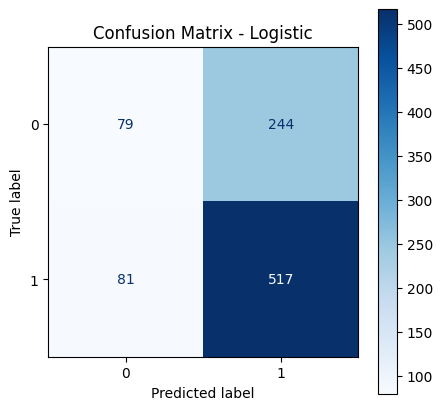

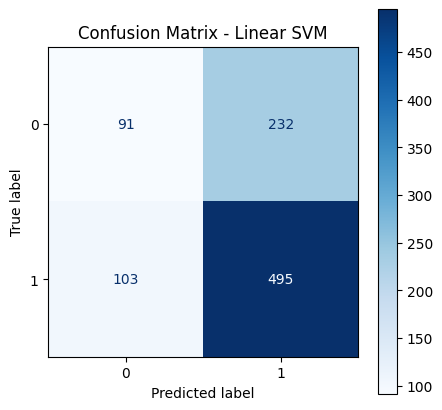

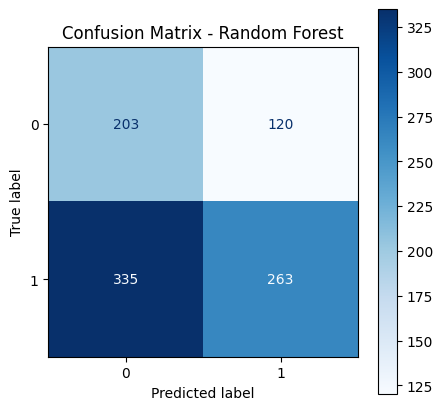

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for name, model in models.items():

    pred = model.predict(X_test)

    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["0", "1"]
    )

    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(ax=ax, values_format="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()